# 1. Основная часть программы

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os
import librosa
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Не находит ресурсы NLTK, надо скачать
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    print("Downloading 'stopwords' corpus...")
    nltk.download("stopwords", download_dir="/root/nltk_data")

try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    print("Downloading 'wordnet' corpus...")
    nltk.download("wordnet", download_dir="/root/nltk_data")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [6]:
# Константы
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/MELD.Raw"
AUDIO_FEATURE_COUNT = 40  # Количество MFCC признаков

# Функция для загрузки данных
def load_data(file_path, data_type):
    """Загружает данные из CSV файла и добавляет столбец 'dataset_type'."""
    try:
        df = pd.read_csv(file_path)
        df['dataset_type'] = data_type  # Добавляем столбец с типом набора данных
        print(f"Данные успешно загружены из {file_path} (тип: {data_type})")
        return df
    except FileNotFoundError:
        print(f"Файл не найден: {file_path}")
        return None
    except Exception as e:
        print(f"Ошибка при загрузке данных из {file_path}: {e}")
        return None

# Функция предобработки данных
def preprocess_text(text):
    """Предобработка текста."""
    text = re.sub(r'[^\w\s]', '', str(text).lower())  # Явное преобразование в строку
    tokens = text.split()
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(tokens)


def get_audio_path(row, data_dir=DATA_DIR):
    """Формирует путь к аудио-файлу."""
    dialogue_id = row['Dialogue_ID']
    utterance_id = row['Utterance_ID']
    dataset_type = row['dataset_type']  # Используем столбец 'dataset_type' из DataFrame

    if not os.path.exists(data_dir):
        print(f"Каталог данных не найден: {data_dir}")
        return None

    if dataset_type == 'train':
        dataset_folder = 'train_splits'
        file_name = f"dia{dialogue_id}_utt{utterance_id}.mp4"
    elif dataset_type == 'dev':
        dataset_folder = 'dev_splits'
        file_name = f"dia{dialogue_id}_utt{utterance_id}.mp4"
    elif dataset_type == 'test':
        dataset_folder = 'test_splits'
        file_name = f"dia{dialogue_id}_utt{utterance_id}.mp4"
    else:
        print(f"Неизвестный тип набора данных: {dataset_type}")
        return None

    audio_path = os.path.join(data_dir, dataset_folder, file_name)

    if not os.path.exists(audio_path):
        print(f"Файл не найден: {audio_path}")
        return None

    return audio_path

def extract_audio_features(audio_path):
    """Извлекает аудио-признаки из MP4-файла."""
    try:
        y, sr = librosa.load(audio_path)
        if y is not None and sr is not None: # Проверка успешной загрузки
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=AUDIO_FEATURE_COUNT)
            mfccs_processed = np.mean(mfccs.T, axis=0)
            return mfccs_processed
        else:
            print(f"Не удалось загрузить аудио для {audio_path}")
            return None
    except Exception as e:
        print(f"Ошибка при извлечении аудио-признаков для {audio_path}: {e}")
        return None

def create_tfidf_features(df, vectorizer=None):
    """Создает TF-IDF признаки из текста."""
    if vectorizer is None:
        vectorizer = TfidfVectorizer()
        X_text = vectorizer.fit_transform(df['Utterance_processed']).toarray()
        print("TF-IDF vectorizer обучен.")
        return X_text, vectorizer
    else:
        X_text = vectorizer.transform(df['Utterance_processed']).toarray()
        return X_text, vectorizer


In [7]:
# Загрузка данных
train_df = load_data("/content/drive/MyDrive/Colab Notebooks/MELD.Raw/train_sent_emo.csv", "train")
dev_df = load_data("/content/drive/MyDrive/Colab Notebooks/MELD.Raw/dev_sent_emo.csv", "dev")
test_df = load_data("/content/drive/MyDrive/Colab Notebooks/MELD.Raw/test_sent_emo.csv", "test")

Данные успешно загружены из /content/drive/MyDrive/Colab Notebooks/MELD.Raw/train_sent_emo.csv (тип: train)
Данные успешно загружены из /content/drive/MyDrive/Colab Notebooks/MELD.Raw/dev_sent_emo.csv (тип: dev)
Данные успешно загружены из /content/drive/MyDrive/Colab Notebooks/MELD.Raw/test_sent_emo.csv (тип: test)


In [8]:
# Предварительная обработка текста
train_df['Utterance_processed'] = train_df['Utterance'].apply(preprocess_text)
dev_df['Utterance_processed'] = dev_df['Utterance'].apply(preprocess_text)
test_df['Utterance_processed'] = test_df['Utterance'].apply(preprocess_text)

In [8]:
# Создаем столбцы с путями к аудио файлам
train_df['audio_path'] = train_df.apply(get_audio_path, axis=1)
dev_df['audio_path'] = dev_df.apply(get_audio_path, axis=1)
test_df['audio_path'] = test_df.apply(get_audio_path, axis=1)

# Фильтруем DataFrame'ы
train_df_filtered = train_df.dropna(subset=['audio_path', 'StartTime', 'EndTime']).copy()
dev_df_filtered = dev_df.dropna(subset=['audio_path', 'StartTime', 'EndTime']).copy()
test_df_filtered = test_df.dropna(subset=['audio_path', 'StartTime', 'EndTime']).copy()

Файл не найден: /content/drive/MyDrive/Colab Notebooks/MELD.Raw/dev_splits/dia110_utt7.mp4


In [ ]:
# Извлекаем аудио-признаки
train_df_filtered['audio_features'] = train_df_filtered['audio_path'].apply(extract_audio_features)
dev_df_filtered['audio_features'] = dev_df_filtered['audio_path'].apply(extract_audio_features)
test_df_filtered['audio_features'] = test_df_filtered['audio_path'].apply(extract_audio_features)

In [10]:
# Фильтруем DataFrame'ы еще раз после извлечения аудио-признаков
train_df_filtered = train_df_filtered.dropna(subset=['audio_features']).copy()
dev_df_filtered = dev_df_filtered.dropna(subset=['audio_features']).copy()
test_df_filtered = test_df_filtered.dropna(subset=['audio_features']).copy()

# Преобразуем audio_features в numpy array
X_train_audio = np.array(train_df_filtered['audio_features'].tolist())
X_dev_audio = np.array(dev_df_filtered['audio_features'].tolist())
X_test_audio = np.array(test_df_filtered['audio_features'].tolist())

# Создаем TF-IDF матрицы
X_train_text, vectorizer = create_tfidf_features(train_df_filtered)
X_dev_text, _ = create_tfidf_features(dev_df_filtered, vectorizer)
X_test_text, _ = create_tfidf_features(test_df_filtered, vectorizer)

# Выделяем целевую переменную
y_train = train_df_filtered['Emotion']
y_dev = dev_df_filtered['Emotion']
y_test = test_df_filtered['Emotion']

TF-IDF vectorizer обучен.


## Только текстовые признаки

In [11]:
# Нормализация текстовых признаков
scaler_text = StandardScaler()
X_train_text_scaled = scaler_text.fit_transform(X_train_text)
X_dev_text_scaled = scaler_text.transform(X_dev_text)
X_test_text_scaled = scaler_text.transform(X_test_text)

def train_and_evaluate_text(model, X_train, y_train, X_dev, y_dev, model_name):
    print(f"\nTraining and evaluating {model_name} (Text Only)...")
    model.fit(X_train, y_train)
    y_pred_dev = model.predict(X_dev)
    print(f"{model_name} - результаты на валидационном наборе (Текст):")
    print(classification_report(y_dev, y_pred_dev))
    print("Accuracy:", accuracy_score(y_dev, y_pred_dev))
    print("-" * 50)
    return model

# Задаем параметры моделей для текстовых признаков
svm_params_text = {'C': 1, 'kernel': 'rbf'}
dt_params_text = {'max_depth': 10}
knn_params_text = {'n_neighbors': 5}
rf_params_text = {'n_estimators': 100, 'max_depth': 10}

# Создаем и обучаем модели на ТЕКСТОВЫХ признаках
svm_model_text = train_and_evaluate_text(SVC(**svm_params_text), X_train_text_scaled, y_train, X_dev_text_scaled, y_dev, "SVM (Text)")
dt_model_text = train_and_evaluate_text(DecisionTreeClassifier(**dt_params_text), X_train_text_scaled, y_train, X_dev_text_scaled, y_dev, "Decision Tree (Text)")
knn_model_text = train_and_evaluate_text(KNeighborsClassifier(**knn_params_text), X_train_text_scaled, y_train, X_dev_text_scaled, y_dev, "KNN (Text)")
rf_model_text = train_and_evaluate_text(RandomForestClassifier(**rf_params_text), X_train_text_scaled, y_train, X_dev_text_scaled, y_dev, "Random Forest (Text)")


Training and evaluating SVM (Text) (Text Only)...
SVM (Text) - результаты на валидационном наборе (Текст):
              precision    recall  f1-score   support

       anger       0.38      0.02      0.04       153
     disgust       1.00      0.09      0.17        22
        fear       0.50      0.03      0.05        40
         joy       0.53      0.10      0.17       163
     neutral       0.45      0.98      0.62       469
     sadness       0.67      0.07      0.13       111
    surprise       0.59      0.15      0.24       150

    accuracy                           0.46      1108
   macro avg       0.59      0.21      0.20      1108
weighted avg       0.51      0.46      0.34      1108

Accuracy: 0.4620938628158845
--------------------------------------------------

Training and evaluating Decision Tree (Text) (Text Only)...
Decision Tree (Text) - результаты на валидационном наборе (Текст):
              precision    recall  f1-score   support

       anger       0.17      0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Только аудио

In [12]:
# Нормализация аудио признаков
scaler_audio = StandardScaler()
X_train_audio_scaled = scaler_audio.fit_transform(X_train_audio)
X_dev_audio_scaled = scaler_audio.transform(X_dev_audio)
X_test_audio_scaled = scaler_audio.transform(X_test_audio)

def train_and_evaluate_audio(model, X_train, y_train, X_dev, y_dev, model_name):
    print(f"\nTraining and evaluating {model_name} (Audio Only)...")
    model.fit(X_train, y_train)
    y_pred_dev = model.predict(X_dev)
    print(f"{model_name} - результаты на валидационном наборе (Аудио):")
    print(classification_report(y_dev, y_pred_dev))
    print("Accuracy:", accuracy_score(y_dev, y_pred_dev))
    print("-" * 50)
    return model

# Задаем параметры моделей для аудио признаков
svm_params_audio = {'C': 1, 'kernel': 'rbf'}
dt_params_audio = {'max_depth': 10}
knn_params_audio = {'n_neighbors': 5}
rf_params_audio = {'n_estimators': 100, 'max_depth': 10}

# Создаем и обучаем модели на АУДИО признаках
svm_model_audio = train_and_evaluate_audio(SVC(**svm_params_audio), X_train_audio_scaled, y_train, X_dev_audio_scaled, y_dev, "SVM (Audio)")
dt_model_audio = train_and_evaluate_audio(DecisionTreeClassifier(**dt_params_audio), X_train_audio_scaled, y_train, X_dev_audio_scaled, y_dev, "Decision Tree (Audio)")
knn_model_audio = train_and_evaluate_audio(KNeighborsClassifier(**knn_params_audio), X_train_audio_scaled, y_train, X_dev_audio_scaled, y_dev, "KNN (Audio)")
rf_model_audio = train_and_evaluate_audio(RandomForestClassifier(**rf_params_audio), X_train_audio_scaled, y_train, X_dev_audio_scaled, y_dev, "Random Forest (Audio)")



Training and evaluating SVM (Audio) (Audio Only)...
SVM (Audio) - результаты на валидационном наборе (Аудио):
              precision    recall  f1-score   support

       anger       0.42      0.07      0.11       153
     disgust       0.00      0.00      0.00        22
        fear       0.00      0.00      0.00        40
         joy       0.00      0.00      0.00       163
     neutral       0.43      1.00      0.60       469
     sadness       0.00      0.00      0.00       111
    surprise       0.00      0.00      0.00       150

    accuracy                           0.43      1108
   macro avg       0.12      0.15      0.10      1108
weighted avg       0.24      0.43      0.27      1108

Accuracy: 0.4305054151624549
--------------------------------------------------

Training and evaluating Decision Tree (Audio) (Audio Only)...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Decision Tree (Audio) - результаты на валидационном наборе (Аудио):
              precision    recall  f1-score   support

       anger       0.23      0.16      0.19       153
     disgust       0.00      0.00      0.00        22
        fear       0.00      0.00      0.00        40
         joy       0.12      0.09      0.10       163
     neutral       0.45      0.79      0.58       469
     sadness       0.20      0.02      0.03       111
    surprise       0.16      0.05      0.07       150

    accuracy                           0.38      1108
   macro avg       0.17      0.16      0.14      1108
weighted avg       0.28      0.38      0.30      1108

Accuracy: 0.37906137184115524
--------------------------------------------------

Training and evaluating KNN (Audio) (Audio Only)...
KNN (Audio) - результаты на валидационном наборе (Аудио):
              precision    recall  f1-score   support

       anger       0.16      0.14      0.15       153
     disgust       0.14      0.09 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Аудио + текст

In [13]:
# Объединяем признаки
X_train_combined = np.concatenate((X_train_text_scaled, X_train_audio_scaled), axis=1)
X_dev_combined = np.concatenate((X_dev_text_scaled, X_dev_audio_scaled), axis=1)
X_test_combined = np.concatenate((X_test_text_scaled, X_test_audio_scaled), axis=1)

def train_and_evaluate_combined(model, X_train, y_train, X_dev, y_dev, model_name):
    print(f"\nTraining and evaluating {model_name} (Combined)...")
    model.fit(X_train, y_train)
    y_pred_dev = model.predict(X_dev)
    print(f"{model_name} - результаты на валидационном наборе (Объединенные признаки):")
    print(classification_report(y_dev, y_pred_dev))
    print("Accuracy:", accuracy_score(y_dev, y_pred_dev))
    print("-" * 50)
    return model

# Задаем параметры моделей для объединенных признаков
svm_params_combined = {'C': 1, 'kernel': 'rbf'}
dt_params_combined = {'max_depth': 10}
knn_params_combined = {'n_neighbors': 5}
rf_params_combined = {'n_estimators': 100, 'max_depth': 10}

# Создаем и обучаем модели на ОБЪЕДИНЕННЫХ признаках
svm_model_combined = train_and_evaluate_combined(SVC(**svm_params_combined), X_train_combined, y_train, X_dev_combined, y_dev, "SVM (Combined)")
dt_model_combined = train_and_evaluate_combined(DecisionTreeClassifier(**dt_params_combined), X_train_combined, y_train, X_dev_combined, y_dev, "Decision Tree (Combined)")
knn_model_combined = train_and_evaluate_combined(KNeighborsClassifier(**knn_params_combined), X_train_combined, y_train, X_dev_combined, y_dev, "KNN (Combined)")
rf_model_combined = train_and_evaluate_combined(RandomForestClassifier(**rf_params_combined), X_train_combined, y_train, X_dev_combined, y_dev, "Random Forest (Combined)")


Training and evaluating SVM (Combined) (Combined)...
SVM (Combined) - результаты на валидационном наборе (Объединенные признаки):
              precision    recall  f1-score   support

       anger       0.38      0.02      0.04       153
     disgust       1.00      0.09      0.17        22
        fear       0.50      0.03      0.05        40
         joy       0.55      0.10      0.17       163
     neutral       0.45      0.98      0.62       469
     sadness       0.67      0.07      0.13       111
    surprise       0.59      0.15      0.24       150

    accuracy                           0.46      1108
   macro avg       0.59      0.21      0.20      1108
weighted avg       0.51      0.46      0.34      1108

Accuracy: 0.4611913357400722
--------------------------------------------------

Training and evaluating Decision Tree (Combined) (Combined)...
Decision Tree (Combined) - результаты на валидационном наборе (Объединенные признаки):
              precision    recall  f1-sco

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## График для сравнения F1-меры

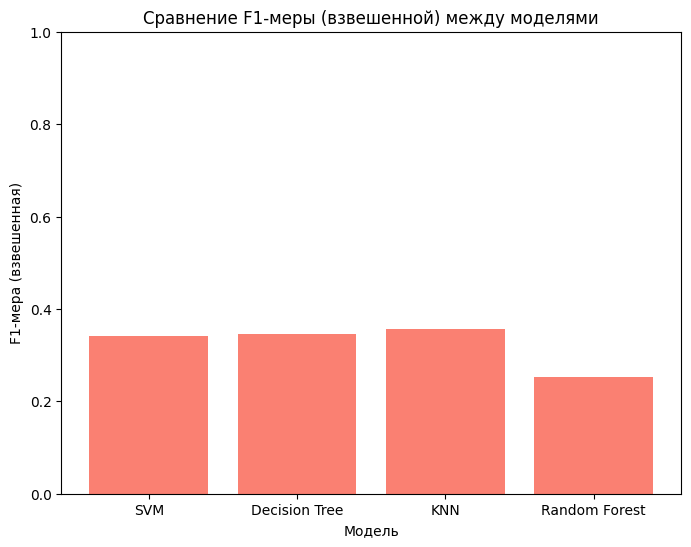

In [15]:
# График для сравнения F1-меры (взвешенной) между моделями:
model_names = ['SVM', 'Decision Tree', 'KNN', 'Random Forest']
f1_scores_weighted = [f1_score(y_dev, svm_model_combined.predict(X_dev_combined), average='weighted'),
                       f1_score(y_dev, dt_model_combined.predict(X_dev_combined), average='weighted'),
                       f1_score(y_dev, knn_model_combined.predict(X_dev_combined), average='weighted'),
                       f1_score(y_dev, rf_model_combined.predict(X_dev_combined), average='weighted')]

plt.figure(figsize=(8, 6))
plt.bar(model_names, f1_scores_weighted, color='salmon')
plt.xlabel("Модель")
plt.ylabel("F1-мера (взвешенная)")
plt.title("Сравнение F1-меры (взвешенной) между моделями")
plt.ylim(0, 1)
plt.show()

## Оценка лучшей модели на тестовом наборе

In [16]:
# Выбираем KNN как лучшую модель и оцениваем ее на тестовом наборе
best_model = knn_model_combined
y_pred_test = best_model.predict(X_test_combined)
print("Результаты лучшей модели на тестовом наборе:")
print(classification_report(y_test, y_pred_test))
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("-" * 50)

Результаты лучшей модели на тестовом наборе:
              precision    recall  f1-score   support

       anger       0.19      0.12      0.14       345
     disgust       0.21      0.07      0.11        68
        fear       0.08      0.04      0.05        50
         joy       0.29      0.26      0.27       402
     neutral       0.53      0.70      0.60      1256
     sadness       0.39      0.08      0.13       208
    surprise       0.24      0.25      0.24       281

    accuracy                           0.43      2610
   macro avg       0.28      0.22      0.22      2610
weighted avg       0.39      0.43      0.39      2610

Accuracy: 0.4256704980842912
--------------------------------------------------


## Выводы

**Низкая общая производительность**: Общая accuracy всех моделей довольно низкая (около 40-46%), что указывает на то, что модели в целом не очень хорошо справляются с классификацией эмоций.

**Сильная несбалансированность классов**: Несбалансированность классов сильно влияет на результаты. Модели, кажется, предвзяты в сторону наиболее представленных классов (например, 'neutral'), но плохо справляются с редкими классами (например, 'disgust', 'fear').

**Проблемы с precision и recall**: У всех моделей наблюдается низкий precision и recall для большинства классов, особенно для редких. Это означает, что модели часто делают ошибки при предсказании редких классов (низкий recall) и часто неправильно классифицируют другие классы как редкие (низкий precision).

**SVM**: Показывает немного лучшие результаты, чем другие модели. Тем не менее, даже у SVM precision и recall для большинства классов остаются низкими.  В частности, precision для 'disgust' равен 1.0, но recall всего 0.09. Это указывает на то, что когда SVM предсказывает 'disgust', это почти всегда верно, но он пропускает большую часть фактических случаев 'disgust'.

**Decision Tree**:  Показывает очень плохие результаты. Precision для большинства классов вообще равен 0, вероятно, из-за переобучения или недостаточной генерализации. Это указывает на то, что дерево решений слишком сложное для данной задачи и не способно уловить закономерности в данных, а скорее запоминает обучающие примеры.

**KNN**: Результаты хуже, чем у SVM, но лучше, чем у Decision Tree. KNN плохо работает с высокоразмерными и разреженными данными. Требует тщательной настройки.

**Random Forest**: Аналогично Decision Tree, Random Forest имеет precision, равный 0 для некоторых классов. Это очень странно, и это может означать, что либо что-то пошло не так с кодом, либо Random Forest каким-то образом переобучается настолько сильно, что совсем не может предсказывать какие-либо экземпляры этих классов.

Для улучшения результатов можно попробовать:
*   Увеличить размер обучающего набора.
*   Применить методы балансировки классов.
*   Провести подбор параметров.
*   Попробовать другие алгоритмы машинного обучения.

# Эксперименты для улучшения результата

Результаты при выбранных параметра совсем низкие. Также присутсвует сильный дисбаланс классов. Поэксперементирую с текстовыми признаками. Попробую оставить матрицы в разреженном формате.

In [10]:
def create_tfidf_features(df, vectorizer):
    """Создает TF-IDF признаки из текста.  Больше не обучает векторизатор!"""
    X_text = vectorizer.transform(df['Utterance_processed'])
    return X_text


# 1. Создаем векторизатор
vectorizer = TfidfVectorizer()

# 2. Обучаем векторизатор и получаем признаки для обучающей выборки
X_train_text = vectorizer.fit_transform(train_df['Utterance_processed']) # fit_transform здесь

# 3. Преобразуем dev и test данные, используя ОБУЧЕННЫЙ векторизатор
X_dev_text = create_tfidf_features(dev_df, vectorizer)  # Только transform
X_test_text = create_tfidf_features(test_df, vectorizer) # Только transform

# Убедимся, что типы данных правильные (разреженные матрицы)
print(type(X_train_text))
print(type(X_dev_text))
print(type(X_test_text))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [11]:
# Выделяем целевую переменную
y_train = train_df['Emotion']
y_dev = dev_df['Emotion']
y_test = test_df['Emotion']

In [12]:
def train_and_evaluate_text(model, X_train, y_train, X_dev, y_dev, model_name):
    print(f"\nTraining and evaluating {model_name} (Text Only)...")
    model.fit(X_train, y_train)
    y_pred_dev = model.predict(X_dev)
    print(f"{model_name} - результаты на валидационном наборе (Текст):")
    print(classification_report(y_dev, y_pred_dev))
    print("Accuracy:", accuracy_score(y_dev, y_pred_dev))
    print("-" * 50)
    return model

# Задаем параметры моделей для текстовых признаков
svm_params_text = {'C': 1, 'kernel': 'rbf'}  # Начнем с дефолтных
dt_params_text = {'max_depth': 10}            # Начнем с дефолтных
knn_params_text = {'n_neighbors': 5}          # Начнем с дефолтных
rf_params_text = {'n_estimators': 100, 'max_depth': 10} # Начнем с дефолтных

# Создаем и обучаем модели на ТЕКСТОВЫХ признаках
svm_model_text = train_and_evaluate_text(SVC(**svm_params_text), X_train_text, y_train, X_dev_text, y_dev, "SVM (Text)")
dt_model_text = train_and_evaluate_text(DecisionTreeClassifier(**dt_params_text), X_train_text, y_train, X_dev_text, y_dev, "Decision Tree (Text)")
knn_model_text = train_and_evaluate_text(KNeighborsClassifier(**knn_params_text), X_train_text, y_train, X_dev_text, y_dev, "KNN (Text)")
rf_model_text = train_and_evaluate_text(RandomForestClassifier(**rf_params_text), X_train_text, y_train, X_dev_text, y_dev, "Random Forest (Text)")


Training and evaluating SVM (Text) (Text Only)...
SVM (Text) - результаты на валидационном наборе (Текст):
              precision    recall  f1-score   support

       anger       0.60      0.06      0.11       153
     disgust       1.00      0.09      0.17        22
        fear       1.00      0.03      0.05        40
         joy       0.50      0.15      0.23       163
     neutral       0.47      0.97      0.63       470
     sadness       0.63      0.11      0.18       111
    surprise       0.55      0.19      0.28       150

    accuracy                           0.48      1109
   macro avg       0.68      0.23      0.24      1109
weighted avg       0.55      0.48      0.38      1109

Accuracy: 0.47971145175834085
--------------------------------------------------

Training and evaluating Decision Tree (Text) (Text Only)...
Decision Tree (Text) - результаты на валидационном наборе (Текст):
              precision    recall  f1-score   support

       anger       0.14      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


KNN (Text) - результаты на валидационном наборе (Текст):
              precision    recall  f1-score   support

       anger       0.26      0.14      0.18       153
     disgust       0.33      0.14      0.19        22
        fear       0.25      0.05      0.08        40
         joy       0.28      0.20      0.24       163
     neutral       0.48      0.68      0.56       470
     sadness       0.60      0.11      0.18       111
    surprise       0.27      0.39      0.32       150

    accuracy                           0.40      1109
   macro avg       0.35      0.24      0.25      1109
weighted avg       0.39      0.40      0.37      1109

Accuracy: 0.4030658250676285
--------------------------------------------------

Training and evaluating Random Forest (Text) (Text Only)...
Random Forest (Text) - результаты на валидационном наборе (Текст):
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       153
     disgust       0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Результат почти не изменился. Попробую подобрать параметры при помощи GridSearchCV

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],  # Диапазон C
    'kernel': ['linear', 'rbf'], # Ядра
}

grid_search = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='f1_weighted') # Кросс-валидация

grid_search.fit(X_train_text, y_train)

print("Лучшие параметры:", grid_search.best_params_)
best_svm_text = grid_search.best_estimator_

Лучшие параметры: {'C': 1, 'kernel': 'rbf'}


Подобрал те же параметры, что и использовались. Попробую Расширить сетку поиска.

In [14]:
param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 2, 5, 10],  # Больше значений C вокруг 1
    'kernel': ['rbf'], # Оставьте только rbf
    'gamma': ['scale', 'auto', 0.1, 1]
}

grid_search = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='f1_weighted') # Кросс-валидация

grid_search.fit(X_train_text, y_train)

print("Лучшие параметры:", grid_search.best_params_)
best_svm_text = grid_search.best_estimator_

Лучшие параметры: {'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}


Получились другие параметры, попробуем их. Также добавлю class_weight='balanced' для балансировки классов

In [15]:
def train_and_evaluate_text2(model, X_train, y_train, X_dev, y_dev, model_name):
    """Обучает модель и выводит отчет о классификации и точность."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)

    print(f"Результаты для {model_name}:")
    print(classification_report(y_dev, y_pred))
    print(f"Точность: {accuracy_score(y_dev, y_pred)}")
    return model # Возвращаем обученную модель

# Параметры
svm_params_text = {'C': 2, 'gamma': 'scale', 'kernel': 'rbf', 'class_weight': 'balanced'}

# Обучение и оценка модели
svm_model_text = train_and_evaluate_text2(SVC(**svm_params_text), X_train_text, y_train, X_dev_text, y_dev, "SVM (Text)")

Результаты для SVM (Text):
              precision    recall  f1-score   support

       anger       0.23      0.17      0.20       153
     disgust       0.30      0.14      0.19        22
        fear       0.16      0.07      0.10        40
         joy       0.32      0.35      0.34       163
     neutral       0.51      0.60      0.56       470
     sadness       0.47      0.19      0.27       111
    surprise       0.34      0.43      0.38       150

    accuracy                           0.41      1109
   macro avg       0.33      0.28      0.29      1109
weighted avg       0.40      0.41      0.40      1109

Точность: 0.4138863841298467


**Общая точность**: Уменьшилась с 46% до 41%. Это означает, что общая способность модели правильно классифицировать примеры ухудшилась.

**F1-score**: F1-score показывает, что баланс между precision и recall для каждого класса так же изменился не сильно. В целом, weighted avg даже стал чуточку повыше, но это не стоит большой разницы.

**Ухудшение в некоторых классах**: Особо заметно ухудшение в классах 'anger' (precision упал с 0.38 до 0.23, recall с 0.02 до 0.17), 'disgust' (precision упал с 1.00 до 0.30, recall с 0.09 до 0.14), 'fear' (precision упал с 0.50 до 0.16, recall с 0.03 до 0.07).

Проанализируем ошибки SVM

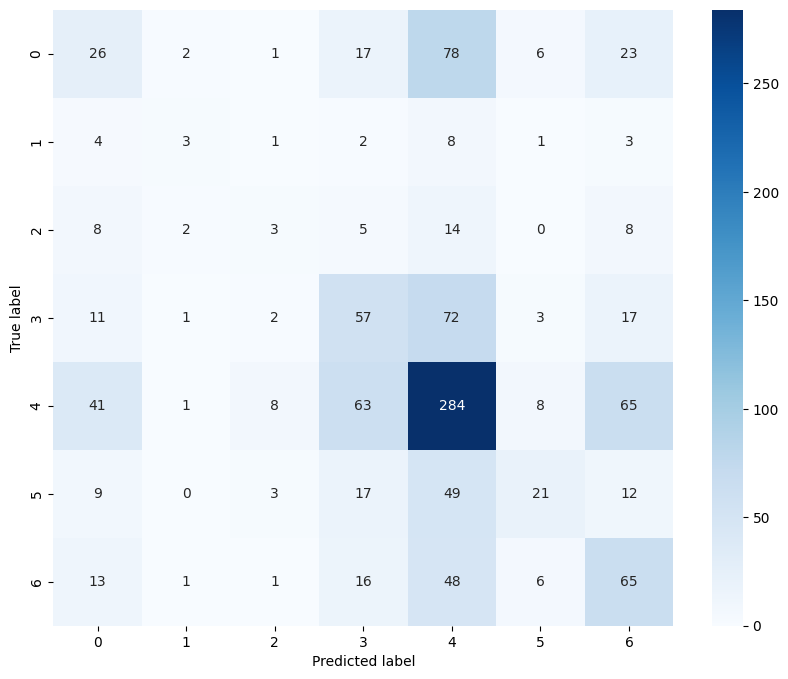

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Получаем предсказания лучшей модели на dev-наборе
y_pred_dev = best_svm_text.predict(X_dev_text)

# Строим матрицу ошибок
cm = confusion_matrix(y_dev, y_pred_dev)

# Визуализируем матрицу ошибок
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

**Доминирование класса 4**: Класс 4 (если смотреть по диагонали) имеет наибольшее количество правильных предсказаний (284). Это означает, что этот класс лучше всего распознается моделью. Вероятно, это самый распространенный класс в данных.

**Проблемы с классами 1 и 2**: Классы 1 и 2 демонстрируют очень низкое количество правильных предсказаний (4 и 2, соответственно). Это указывает на то, что модель очень плохо справляется с распознаванием этих классов. Они могут быть редкими и/или трудными для различения на основе имеющихся признаков. Маленькое количество класса 5 (21) и 6 (65) тоже говорит о проблемах.

**Смешение классов**: Модель путает различные классы друг с другом. Вне диагонали видно, что есть значительное количество примеров, которые были предсказаны неправильно.

**Класс 0**: 4 примера правильно классифицированы, но 41 раз класс 4 был неправильно отнесен к классу 0. Это серьезная проблема.

**Класс 3**: Модель часто путает класс 3 с классом 4 (72 примера класса 3 были ошибочно предсказаны как класс 4).

**Класс 4**: Модель чаще всего правильно классифицирует класс 4 (284 примера). Тем не менее, есть много ошибок: 41 пример класса 4 ошибочно предсказывается как класс 0,  63 - как класс 3 и 65 - как класс 6. Это показывает, что класс 4 имеет сходство с классами 0 и 3.

**Класс 6**: 13 примеров отнесено к 0, 16 - к 3 и 48 - к 4.

**В некоторых случаях определение эмоции только по тексту невозможно. Необходимо включать другие признаки - из аудио и/или видео.**